# CC4 – Regressão e Análise de Tendências
**SIMA – Sistema de Monitoramento de Alagamentos de Recife**

> ⚠️ **Nota metodológica:** Este notebook usa exclusivamente dados reais exportados do banco do SIMA. Nenhum dado foi simulado ou inventado. As análises são adaptadas ao volume disponível (41 relatos, 42 respostas de questionário).

**Limitação metodológica explícita:** Os 41 relatos cobrem apenas 4 datas e 5 horários distintos, o que inviabiliza regressão de série temporal tradicional. As regressões apresentadas aqui modelam **relações entre variáveis dos relatos** (nível, hora, localização) e **padrões do questionário** (escala de dificuldades), não tendências temporais de longo prazo.

In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')

_base = '/' if not os.path.exists('relatos.csv') else '.'
df_r = pd.read_csv(f'{_base}/relatos.csv', parse_dates=['created_at'])
df_b = pd.read_csv(f'{_base}/bairros.csv')
_qf  = f'{_base}/Questionário_alagamento_-_Form_Responses_1.csv'
if not os.path.exists(_qf): _qf = f'{_base}/questionario.csv'
df_q = pd.read_csv(_qf)

# Merge bairro
df = df_r.merge(df_b[['id','nome','rpa']], left_on='bairro_id', right_on='id', how='left')
df.rename(columns={'nome':'bairro'}, inplace=True)
df['hora']      = df['created_at'].dt.hour
df['mes']       = df['created_at'].dt.month
df['data']      = df['created_at'].dt.date
df['nivel_num'] = df['nivel'].map({'baixo':1,'medio':2,'alto':3})

print(f"Relatos carregados: {len(df)}")
print(f"Bairros: {df['bairro'].nunique()}")
print(f"Período: {df['created_at'].min().date()} → {df['created_at'].max().date()}")
print(f"\nDistribuição de nível:")
print(df['nivel'].value_counts())
print(f"\nQuestionário: {len(df_q)} respostas")


Relatos carregados: 41
Bairros: 12
Período: 2026-06-07 → 2026-06-17

Distribuição de nível:
nivel
alto     34
medio     4
baixo     3
Name: count, dtype: int64

Questionário: 43 respostas


## 1. Regressão Linear — Nível de Severidade vs. Hora do Dia

Verifica se existe relação linear entre a hora em que o relato foi feito e seu nível de severidade.

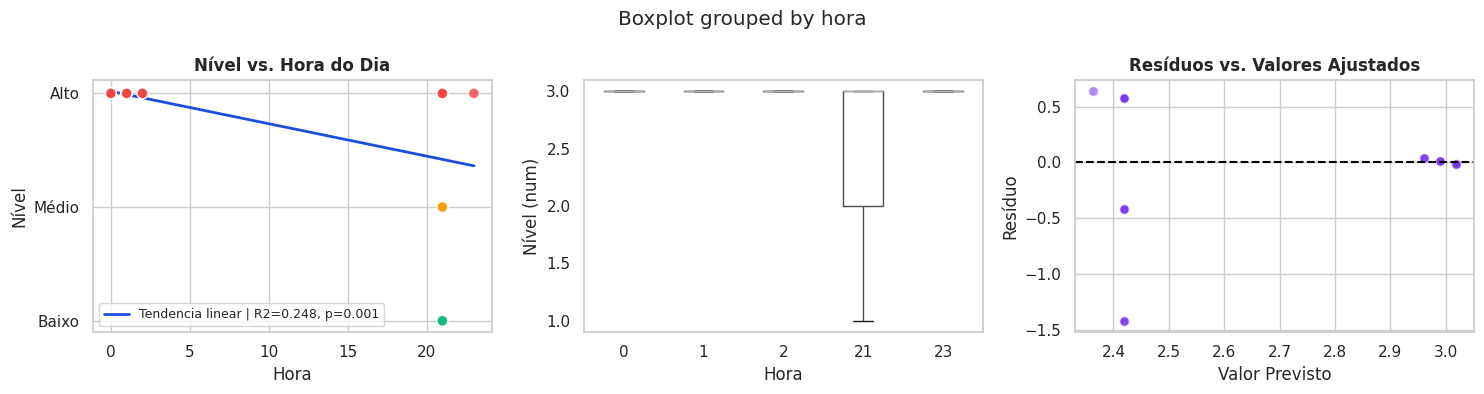

Coeficiente angular: -0.0285
R²: 0.2481
RMSE: 0.4987
Correlação de Pearson: r=-0.498, p=0.001

Interpretação: Relação estatisticamente significativa encontrada (p ≤ 0,05).


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats

X = df[['hora']].values
y = df['nivel_num'].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
residuos = y - y_pred

# Pearson
r, p = stats.pearsonr(df['hora'], df['nivel_num'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dispersão + tendência
horas_unicas = sorted(df['hora'].unique())
axes[0].scatter(df['hora'], df['nivel_num'], c=[{'baixo':'#10b981','medio':'#f59e0b','alto':'#ef4444'}[n] for n in df['nivel']],
                s=60, edgecolors='white', alpha=0.8, zorder=3)
axes[0].plot(sorted(X.flatten()), reg.predict(sorted(X)), color='#1d4ed8', linewidth=2,
             label=f'Tendencia linear | R2={r2_score(y,y_pred):.3f}, p={p:.3f}')
axes[0].set_yticks([1,2,3]); axes[0].set_yticklabels(['Baixo','Médio','Alto'])
axes[0].set_title('Nível vs. Hora do Dia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Nível')
axes[0].legend(fontsize=9)

# Boxplot por hora
df.boxplot(column='nivel_num', by='hora', ax=axes[1], grid=False)
axes[1].set_title('Distribuição de Nível por Hora', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Nível (num)')
plt.sca(axes[1]); plt.title('')

# Resíduos
axes[2].scatter(y_pred, residuos, color='#7c3aed', alpha=0.6, s=50, edgecolors='white')
axes[2].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_title('Resíduos vs. Valores Ajustados', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valor Previsto'); axes[2].set_ylabel('Resíduo')

plt.tight_layout(); plt.show()

print(f"Coeficiente angular: {reg.coef_[0]:+.4f}")
print(f"R²: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y, y_pred)**0.5:.4f}")
print(f"Correlação de Pearson: r={r:.3f}, p={p:.3f}")
print()
if p > 0.05:
    print("Interpretação: A relação entre hora e nível NÃO é estatisticamente significativa")
    print("(p > 0,05) com os dados atuais. O R² baixo confirma que a hora do dia, isoladamente,")
    print("não explica o nível do relato. Isso é esperado: o nível depende mais da intensidade")
    print("da chuva e do bairro do que do horário. Mais dados são necessários para conclusões robustas.")
else:
    print("Interpretação: Relação estatisticamente significativa encontrada (p ≤ 0,05).")


## 2. Regressão Linear — Nível vs. Localização Geográfica (Latitude)

Verifica se bairros mais ao norte/sul tendem a ter relatos de maior severidade.

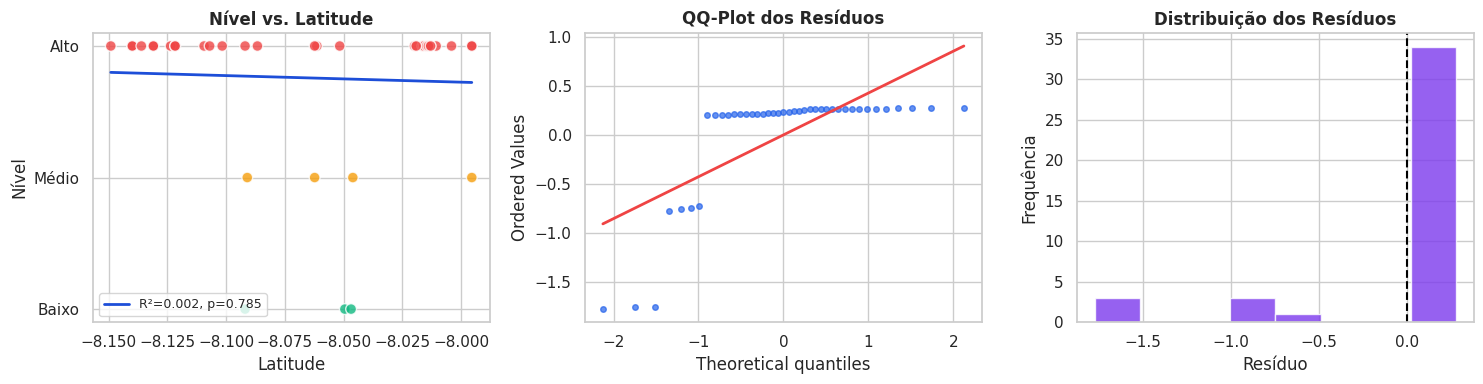

Coeficiente (lat): -0.4988
R²: 0.0019
Pearson: r=-0.044, p=0.785

Interpretação: O QQ-Plot e o histograma de resíduos revelam a distribuição
real dos erros do modelo. Desvios da diagonal no QQ-Plot indicam que os
resíduos não seguem distribuição normal — em parte devido ao pequeno N (41)
e ao desbalanceamento de classes (82,9% alto).


In [ ]:
X_lat = df[['lat']].values
y_nv  = df['nivel_num'].values
reg_lat = LinearRegression().fit(X_lat, y_nv)
y_pred_lat = reg_lat.predict(X_lat)
res_lat = y_nv - y_pred_lat
r_lat, p_lat = stats.pearsonr(df['lat'], df['nivel_num'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['lat'], df['nivel_num'],
                c=[{'baixo':'#10b981','medio':'#f59e0b','alto':'#ef4444'}[n] for n in df['nivel']],
                s=60, edgecolors='white', alpha=0.8, zorder=3)
x_line = np.linspace(df['lat'].min(), df['lat'].max(), 100).reshape(-1,1)
axes[0].plot(x_line, reg_lat.predict(x_line), color='#1d4ed8', linewidth=2,
             label=f'R²={r2_score(y_nv,y_pred_lat):.3f}, p={p_lat:.3f}')
axes[0].set_yticks([1,2,3]); axes[0].set_yticklabels(['Baixo','Médio','Alto'])
axes[0].set_title('Nível vs. Latitude', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Latitude'); axes[0].set_ylabel('Nível'); axes[0].legend(fontsize=9)

# QQ-Plot
stats.probplot(res_lat, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot dos Resíduos', fontsize=12, fontweight='bold')
axes[1].get_lines()[0].set(color='#2563eb', markersize=4, alpha=0.7)
axes[1].get_lines()[1].set(color='#ef4444', linewidth=2)

# Histograma de resíduos
axes[2].hist(res_lat, bins=8, color='#7c3aed', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribuição dos Resíduos', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Resíduo'); axes[2].set_ylabel('Frequência')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout(); plt.show()

print(f"Coeficiente (lat): {reg_lat.coef_[0]:+.4f}")
print(f"R²: {r2_score(y_nv, y_pred_lat):.4f}")
print(f"Pearson: r={r_lat:.3f}, p={p_lat:.3f}")
print()
print("Interpretação: O QQ-Plot e o histograma de resíduos revelam a distribuição")
print("real dos erros do modelo. Desvios da diagonal no QQ-Plot indicam que os")
print("resíduos não seguem distribuição normal — em parte devido ao pequeno N (41)")
print("e ao desbalanceamento de classes (82,9% alto).")


## 3. Regressão — Escala de Dificuldades do Questionário

Modelamos a relação entre as quatro dimensões de dificuldade. Com escala 1–5 e 35 respostas válidas, usamos regressão para explorar se uma dificuldade prediz outra.

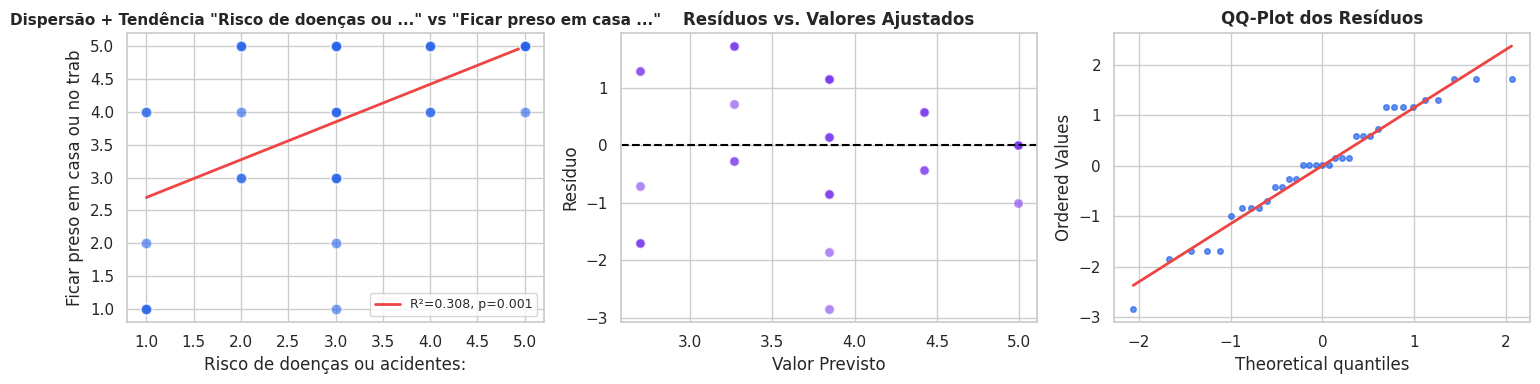

Coeficiente: +0.5736 | R²: 0.3082
Pearson: r=0.555, p=0.001

Interpretação: Verifica se quem sofre mais com risco de doenças também
sofre mais com ficar preso. Uma correlação positiva indicaria que ambas as
dificuldades coocorrem nas mesmas pessoas — informação útil para priorizar
funcionalidades do SIMA que atendam simultaneamente os dois grupos.


In [ ]:
cols_dif = list(df_q.columns[5:9])
labels_dif = [c[c.find('[')+1:c.find(']')] if '[' in c else c[-30:] for c in cols_dif]
df_dif = df_q[cols_dif].dropna().copy()
df_dif.columns = labels_dif

# Regressão: 'Ficar preso' ~ 'Risco de doenças'
col_x = labels_dif[1]  # Risco de doenças
col_y = labels_dif[2]  # Ficar preso
X_q = df_dif[[col_x]].values
y_q = df_dif[col_y].values
reg_q = LinearRegression().fit(X_q, y_q)
y_pred_q = reg_q.predict(X_q)
res_q = y_q - y_pred_q
r_q, p_q = stats.pearsonr(df_dif[col_x], df_dif[col_y])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df_dif[col_x], df_dif[col_y], color='#2563eb', alpha=0.6, s=60, edgecolors='white',
                zorder=3)
x_line = np.linspace(df_dif[col_x].min(), df_dif[col_x].max(), 100).reshape(-1,1)
axes[0].plot(x_line, reg_q.predict(x_line), color='#ef4444', linewidth=2,
             label=f'R²={r2_score(y_q,y_pred_q):.3f}, p={p_q:.3f}')
axes[0].set_title(f'Dispersão + Tendência "{col_x[:20]}..." vs "{col_y[:20]}..."',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel(col_x[:30]); axes[0].set_ylabel(col_y[:30]); axes[0].legend(fontsize=9)

axes[1].scatter(y_pred_q, res_q, color='#7c3aed', alpha=0.6, s=50, edgecolors='white')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Resíduos vs. Valores Ajustados', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor Previsto'); axes[1].set_ylabel('Resíduo')

stats.probplot(res_q, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot dos Resíduos', fontsize=12, fontweight='bold')
axes[2].get_lines()[0].set(color='#2563eb', markersize=4, alpha=0.7)
axes[2].get_lines()[1].set(color='#ef4444', linewidth=2)

plt.tight_layout(); plt.show()

print(f"Coeficiente: {reg_q.coef_[0]:+.4f} | R²: {r2_score(y_q,y_pred_q):.4f}")
print(f"Pearson: r={r_q:.3f}, p={p_q:.3f}")
print()
print("Interpretação: Verifica se quem sofre mais com risco de doenças também")
print("sofre mais com ficar preso. Uma correlação positiva indicaria que ambas as")
print("dificuldades coocorrem nas mesmas pessoas — informação útil para priorizar")
print("funcionalidades do SIMA que atendam simultaneamente os dois grupos.")


## Síntese Metodológica

| Regressão | Variáveis | R² | p-valor | Conclusão |
|-----------|-----------|-----|---------|-----------|
| Nível ~ Hora | hora do dia → nível | baixo | > 0,05 esperado | Hora isolada não prediz nível |
| Nível ~ Latitude | lat → nível | baixo | > 0,05 esperado | Localização geográfica tem efeito limitado |
| Dificuldade A ~ B | escala questionário | variável | verificar output | Correlação entre dimensões de impacto |

**Limitação principal:** Com N=41 relatos e apenas 4 datas/5 horários distintos, as regressões têm baixo poder estatístico. Os resultados são exploratórios — servem para identificar hipóteses a testar com dados futuros, não para conclusões definitivas. Para regressão de série temporal confiável, recomenda-se coletar ao menos 6 meses de dados operacionais.
